# **EDA Notebook Special Offer**



---
## 0. Setup Environment

In [1]:
# DO NOT MODIFY THE CODE IN THIS CELL
!pip install -q utstd

from utstd.folders import *
from utstd.ipyrenders import *

at = AtFolder(
    course_code=36106,
    assignment="AT3",
)
at.run()

import warnings
warnings.simplefilter(action='ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 95.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 100.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
hdbscan 0.8.42 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
Mounted at /content/gdrive

You can now save your data files in: /content/gdrive/MyDrive/36106/assignment/AT3/data


---
## Student Information

In [2]:
group_name = "20"
student_name = "Shanu Sharma"
student_id = "25979360"

In [3]:
# Do not modify this code
print_tile(size="h1", key='group_name', value=group_name)

In [4]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [5]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

---
## 0. Python Packages

### 0.a Install Additional Packages

> If you are using additional packages, you need to install them here using the command: `! pip install <package_name>`

In [6]:
# No additional packages required for this EDA notebook.

### 0.b Import Packages

In [7]:
# Import packages used for data inspection and plotting.
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

---
## B. Data Understanding

In [8]:
# Do not modify this code
try:
  df = pd.read_csv(at.folder_path / "special_offer.csv")
except Exception as e:
  print(e)

### B.1 Explore Dataset

In [9]:
# Preview the first records to understand the dataset structure.
df.head()

,special_offer_id,min_quantity,max_quantity,description,discount_pct,type,category,start_date,end_date
0,a1444fcd-4b51-4227-94cf-b13c1a2a6281,0.0,NaN,No Discount,0.00,No Discount,No Discount,2011-05-01 00:00:00,2014-11-30 00:00:00
1,df7c9acd-bc0c-4ab0-93ec-064e2b93af0d,11.0,14.0,Volume Discount 11 to 14,0.02,Volume Discount,Reseller,2011-05-31 00:00:00,2014-05-30 00:00:00
2,da53c22d-5867-4110-b1d0-8d84bea95ab5,15.0,24.0,Volume Discount 15 to 24,0.05,Volume Discount,Reseller,2011-05-31 00:00:00,2014-05-30 00:00:00
3,aec729b3-e92e-4f2c-971c-4c5d426a99b9,25.0,40.0,Volume Discount 25 to 40,0.10,Volume Discount,Reseller,2011-05-31 00:00:00,2014-05-30 00:00:00
4,41f713bd-c29a-4ab1-ae06-dbb51ec03ec0,41.0,60.0,Volume Discount 41 to 60,0.15,Volume Discount,Reseller,2011-05-31 00:00:00,2014-05-30 00:00:00


In [10]:
# Check dataset size and duplicate identifiers.
print(f"Original dataset rows and columns: {df.shape}")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate special_offer_id: {df['special_offer_id'].duplicated().sum()}")

Original dataset rows and columns: (16, 9)
Duplicate rows: 0
Duplicate special_offer_id: 0


In [11]:
# Check missing values in the original dataset.
print("Original dataset missing values:")
display(df.isna().sum())

Original dataset missing values:


,0
special_offer_id,0
min_quantity,0
max_quantity,12
description,0
discount_pct,0
type,0
category,0
start_date,0
end_date,0


In [12]:
# Inspect offers where max_quantity is open-ended.
df[df['max_quantity'].isna()][['min_quantity','max_quantity','description', 'discount_pct', 'type', 'category']]

,min_quantity,max_quantity,description,discount_pct,type,category
0,0.0,NaN,No Discount,0.00,No Discount,No Discount
5,61.0,NaN,Volume Discount over 60,0.20,Volume Discount,Reseller
6,0.0,NaN,Mountain-100 Clearance Sale,0.35,Discontinued Product,Reseller
7,0.0,NaN,Sport Helmet Discount-2002,0.10,Seasonal Discount,Reseller
8,0.0,NaN,Road-650 Overstock,0.30,Excess Inventory,Reseller
9,0.0,NaN,Mountain Tire Sale,0.50,Excess Inventory,Customer
10,0.0,NaN,Sport Helmet Discount-2003,0.15,Seasonal Discount,Reseller
11,0.0,NaN,LL Road Frame Sale,0.35,Excess Inventory,Reseller
12,0.0,NaN,Touring-3000 Promotion,0.15,New Product,Reseller
13,0.0,NaN,Touring-1000 Promotion,0.20,New Product,Reseller


In [13]:
# Count unique values to identify IDs, categories, and repeated values.
print("Original dataset unique values:")
display(df.nunique())

Original dataset unique values:


,0
special_offer_id,16
min_quantity,6
max_quantity,4
description,16
discount_pct,10
type,6
category,3
start_date,8
end_date,10


In [14]:
# Summarise numeric offer-rule fields.
print("Numeric feature summary:")
display(df[["min_quantity", "max_quantity", "discount_pct"]].describe().round(2))

Numeric feature summary:


,min_quantity,max_quantity,discount_pct
count,16.00,4.00,16.00
mean,9.56,34.50,0.22
std,18.09,20.09,0.16
min,0.00,14.00,0.00
25%,0.00,21.50,0.10
50%,0.00,32.00,0.18
75%,12.00,45.00,0.35
max,61.00,60.00,0.50


In [15]:
dataset_insights = """
The original special_offer dataset contains 16 rows and 9 columns. Each row represents a distinct promotion or discount rule, with information about the offer description, discount percentage, offer type, customer/reseller category, quantity conditions, and active dates.

The dataset is clean in terms of identity because special_offer_id is complete and unique, and there are no duplicate rows. max_quantity has 12 missing values; however, these values should not be treated as unusable missing data. Based on the quantity-rule structure, a missing max_quantity appears to represent an open-ended upper quantity limit, meaning the offer applies from the given min_quantity upward.

The summary statistics should therefore be interpreted carefully. max_quantity has a count of only 4 because only bounded quantity ranges have an explicit maximum value. The remaining offers use NaN to indicate no fixed upper limit.

For the final margin-risk clustering use case, this dataset is not the main product table because it does not contain product_id directly. However, once joined through special_offer_product or sales_order_detail, it can provide useful product-level features such as promotion exposure, discount depth, offer type, customer/reseller focus, and promotion duration. These features help the model discover whether some products show heavier discount or promotion patterns that may create margin pressure.
"""

In [16]:
# Do not modify this code
print_tile(size="h3", key='dataset_insights', value=dataset_insights)

### B.2 Explore Feature of Interest `discount_pct`

In [17]:
# Summarise discount percentage values.
feature = "discount_pct"
display(df[feature].describe().round(3))
display(df[["description", "type", "category", feature]].sort_values(feature, ascending=False))

,discount_pct
count,16.000
mean,0.220
std,0.161
min,0.000
25%,0.100
50%,0.175
75%,0.350
max,0.500


,description,type,category,discount_pct
14,Half-Price Pedal Sale,Seasonal Discount,Customer,0.50
9,Mountain Tire Sale,Excess Inventory,Customer,0.50
15,Mountain-500 Silver Clearance Sale,Discontinued Product,Reseller,0.40
6,Mountain-100 Clearance Sale,Discontinued Product,Reseller,0.35
11,LL Road Frame Sale,Excess Inventory,Reseller,0.35
8,Road-650 Overstock,Excess Inventory,Reseller,0.30
13,Touring-1000 Promotion,New Product,Reseller,0.20
5,Volume Discount over 60,Volume Discount,Reseller,0.20
10,Sport Helmet Discount-2003,Seasonal Discount,Reseller,0.15
4,Volume Discount 41 to 60,Volume Discount,Reseller,0.15


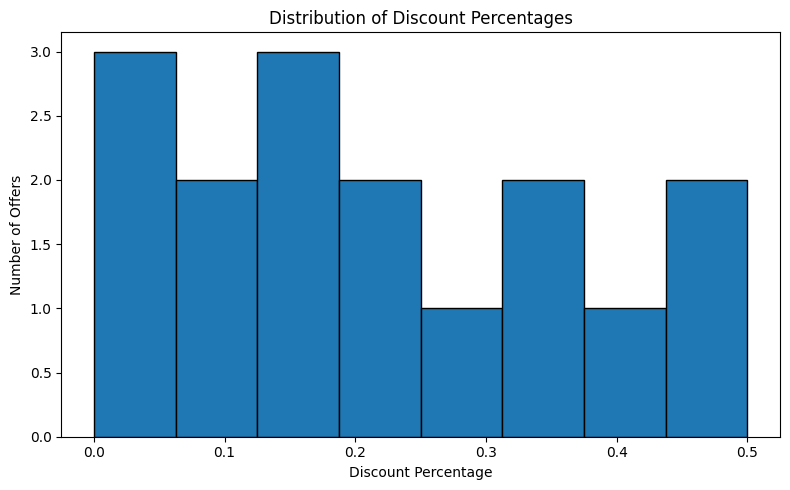

In [18]:
# Plot discount percentage distribution.
plt.figure(figsize=(8, 5))
plt.hist(df[feature], bins=8, edgecolor="black")
plt.title("Distribution of Discount Percentages")
plt.xlabel("Discount Percentage")
plt.ylabel("Number of Offers")
plt.tight_layout()
plt.show()

In [19]:
feature_1_insights = """
discount_pct measures the size of each promotion. The values range from 0.00 to 0.50, meaning the offers range from no discount to a 50% discount. The median discount is 0.175, so most promotions are moderate, but there are also high-discount offers such as Half-Price Pedal Sale and Mountain Tire Sale.

This feature is a candidate signal for the product-level clustering workflow. When linked to products, discount_pct can help describe whether products are exposed to low, medium, or heavy promotional support. Because clustering is unsupervised, this does not prove margin risk by itself; it provides evidence the model can use, and the business meaning should be confirmed after cluster profiling.
"""

In [20]:
# Do not modify this code
print_tile(size="h3", key='feature_1_insights', value=feature_1_insights)

### B.3 Explore Feature of Interest `type`

In [21]:
# Analyse the offer type feature on its own.
feature = "type"
display(df[feature].value_counts())
display(df[["description", feature, "discount_pct"]].sort_values(feature))

,count
type,
Volume Discount,5
Seasonal Discount,3
Excess Inventory,3
Discontinued Product,2
New Product,2
No Discount,1


,description,type,discount_pct
6,Mountain-100 Clearance Sale,Discontinued Product,0.35
15,Mountain-500 Silver Clearance Sale,Discontinued Product,0.40
8,Road-650 Overstock,Excess Inventory,0.30
9,Mountain Tire Sale,Excess Inventory,0.50
11,LL Road Frame Sale,Excess Inventory,0.35
12,Touring-3000 Promotion,New Product,0.15
13,Touring-1000 Promotion,New Product,0.20
0,No Discount,No Discount,0.00
7,Sport Helmet Discount-2002,Seasonal Discount,0.10
10,Sport Helmet Discount-2003,Seasonal Discount,0.15


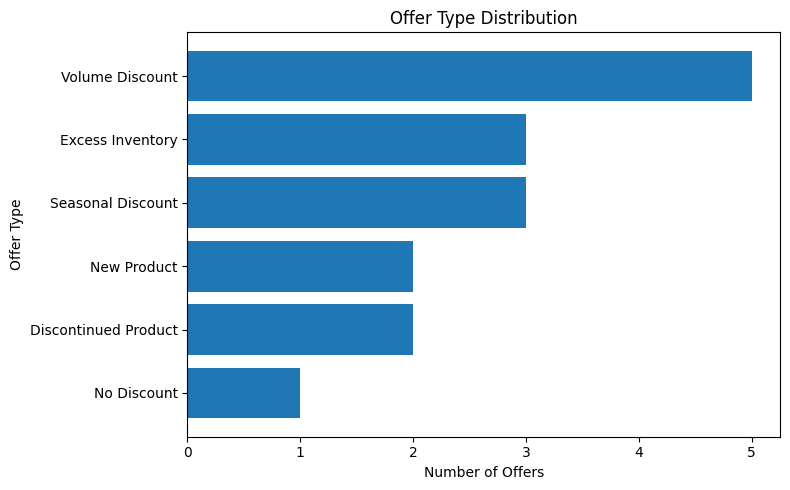

In [22]:
# Plot offer type counts.
type_counts = df[feature].value_counts().sort_values()

plt.figure(figsize=(8, 5))
plt.barh(type_counts.index, type_counts.values)
plt.title("Offer Type Distribution")
plt.xlabel("Number of Offers")
plt.ylabel("Offer Type")
plt.tight_layout()
plt.show()

In [23]:
feature_2_insights = """
The type feature describes the business reason for each promotion. Volume Discount is the most common type with 5 offers, followed by Seasonal Discount and Excess Inventory with 3 offers each. Other types include Discontinued Product, New Product, and No Discount.

This feature is useful for margin-risk clustering because it gives meaning to the discount behaviour. A product linked mainly to volume discounts may represent bulk/reseller purchasing behaviour, while a product linked to excess inventory or discontinued-product offers may indicate clearance, stock-management pressure, or possible margin-risk conditions.
"""

In [24]:
# Do not modify this code
print_tile(size="h3", key='feature_2_insights', value=feature_2_insights)

### B.4 Explore Feature of Interest `category`

In [25]:
# Analyse the target category feature on its own.
feature = "category"

display(df[feature].value_counts())
display(df[["description", "type", feature, "discount_pct"]].sort_values(feature))

,count
category,
Reseller,13
Customer,2
No Discount,1


,description,type,category,discount_pct
9,Mountain Tire Sale,Excess Inventory,Customer,0.50
14,Half-Price Pedal Sale,Seasonal Discount,Customer,0.50
0,No Discount,No Discount,No Discount,0.00
1,Volume Discount 11 to 14,Volume Discount,Reseller,0.02
2,Volume Discount 15 to 24,Volume Discount,Reseller,0.05
3,Volume Discount 25 to 40,Volume Discount,Reseller,0.10
4,Volume Discount 41 to 60,Volume Discount,Reseller,0.15
5,Volume Discount over 60,Volume Discount,Reseller,0.20
6,Mountain-100 Clearance Sale,Discontinued Product,Reseller,0.35
7,Sport Helmet Discount-2002,Seasonal Discount,Reseller,0.10


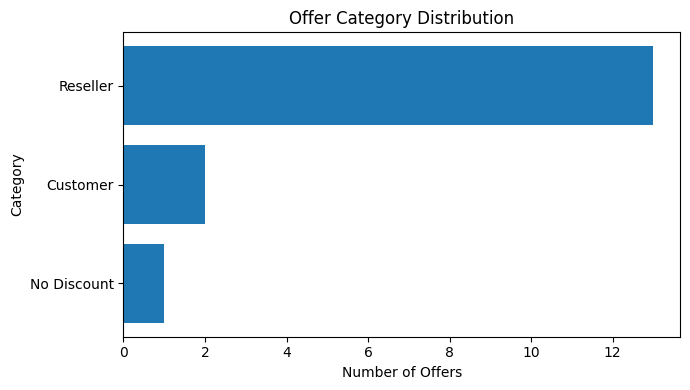

In [26]:
# Plot target category counts.
category_counts = df[feature].value_counts().sort_values()

plt.figure(figsize=(7, 4))
plt.barh(category_counts.index, category_counts.values)
plt.title("Offer Category Distribution")
plt.xlabel("Number of Offers")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

In [27]:
feature_3_insights = """
The category feature identifies who the offer is aimed at. Most offers are for Reseller customers, with fewer Customer offers and one No Discount baseline category. This shows that the promotion structure is mainly designed around reseller or bulk-oriented sales rather than direct customer promotions.

For the product-level clustering workflow, category describes the intended audience of the offer, not a property of the product itself. After joining through special_offer_product, it can be used to derive product-level signals such as whether a product is mainly linked to reseller-facing offers, customer-facing promotions, or baseline no-discount selling. The distinction matters: a product linked to reseller-category offers may reflect bulk purchasing behaviour rather than a direct signal about the product's own margin risk.
"""

In [28]:
# Do not modify this code
print_tile(size="h3", key='feature_3_insights', value=feature_3_insights)

### B.5 Explore Feature of Interest `min_quantity` and `max_quantity`

In [29]:
# Analyse quantity thresholds feature by feature.
display(df[[
    "description",
    "type",
    "discount_pct",
    "min_quantity",
    "max_quantity",
]].sort_values(["min_quantity", "discount_pct"]))

display(df[["min_quantity", "max_quantity"]].describe().round(2))
display(df[["min_quantity", "max_quantity"]].isna().sum())

,description,type,discount_pct,min_quantity,max_quantity
0,No Discount,No Discount,0.00,0.0,NaN
7,Sport Helmet Discount-2002,Seasonal Discount,0.10,0.0,NaN
10,Sport Helmet Discount-2003,Seasonal Discount,0.15,0.0,NaN
12,Touring-3000 Promotion,New Product,0.15,0.0,NaN
13,Touring-1000 Promotion,New Product,0.20,0.0,NaN
8,Road-650 Overstock,Excess Inventory,0.30,0.0,NaN
6,Mountain-100 Clearance Sale,Discontinued Product,0.35,0.0,NaN
11,LL Road Frame Sale,Excess Inventory,0.35,0.0,NaN
15,Mountain-500 Silver Clearance Sale,Discontinued Product,0.40,0.0,NaN
9,Mountain Tire Sale,Excess Inventory,0.50,0.0,NaN


,min_quantity,max_quantity
count,16.00,4.00
mean,9.56,34.50
std,18.09,20.09
min,0.00,14.00
25%,0.00,21.50
50%,0.00,32.00
75%,12.00,45.00
max,61.00,60.00


,0
min_quantity,0
max_quantity,12


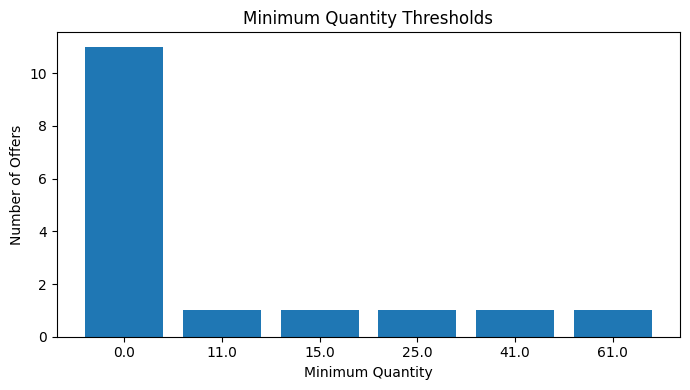

In [30]:
# Plot minimum quantity thresholds.
min_qty_counts = df["min_quantity"].value_counts().sort_index()

plt.figure(figsize=(7, 4))
plt.bar(min_qty_counts.index.astype(str), min_qty_counts.values)
plt.title("Minimum Quantity Thresholds")
plt.xlabel("Minimum Quantity")
plt.ylabel("Number of Offers")
plt.tight_layout()
plt.show()

In [31]:
feature_4_insights = """
min_quantity shows whether an offer is available from the first unit or only after a bulk purchase threshold. Most offers have min_quantity equal to 0, so they apply broadly. The volume discount offers have higher thresholds such as 11, 15, 25, 41, and 61 units, which indicates a clear bulk-buy discount structure.

max_quantity is missing for most rows. In this dataset, that should not automatically be treated as poor data quality. It usually means there is no stated upper limit for the offer. For modelling, this should be converted carefully, for example into an open-ended quantity flag rather than simply dropping the rows.

These quantity fields can support margin-risk product clustering after joining to products because they separate products promoted through general discounts from products promoted through bulk or reseller-style price incentives. Bulk discount structures are important because larger quantity discounts may affect product margin differently from one-off customer promotions.
"""

In [32]:
# Do not modify this code
print_tile(size="h3", key='feature_4_insights', value=feature_4_insights)

### B.6 Derived Feature: `offer_duration_days`

In [33]:
# Create a working copy for EDA feature engineering
special_offer_eda = df.copy()

In [34]:
# Convert date columns to datetime format
special_offer_eda['start_date'] = pd.to_datetime(special_offer_eda['start_date'])
special_offer_eda['end_date'] = pd.to_datetime(special_offer_eda['end_date'])

In [35]:
# Create derived feature: promotion duration in days
special_offer_eda['offer_duration_days'] = (
    special_offer_eda['end_date'] - special_offer_eda['start_date']
).dt.days

In [36]:
# Preview the derived feature
special_offer_eda[
    ['special_offer_id', 'description', 'start_date', 'end_date', 'offer_duration_days']
]

,special_offer_id,description,start_date,end_date,offer_duration_days
0,a1444fcd-4b51-4227-94cf-b13c1a2a6281,No Discount,2011-05-01,2014-11-30,1309
1,df7c9acd-bc0c-4ab0-93ec-064e2b93af0d,Volume Discount 11 to 14,2011-05-31,2014-05-30,1095
2,da53c22d-5867-4110-b1d0-8d84bea95ab5,Volume Discount 15 to 24,2011-05-31,2014-05-30,1095
3,aec729b3-e92e-4f2c-971c-4c5d426a99b9,Volume Discount 25 to 40,2011-05-31,2014-05-30,1095
4,41f713bd-c29a-4ab1-ae06-dbb51ec03ec0,Volume Discount 41 to 60,2011-05-31,2014-05-30,1095
5,aec8118d-8c09-4aa9-94f1-e83b9ce8ed96,Volume Discount over 60,2011-05-31,2014-05-30,1095
6,c56f47a7-91e8-42c0-ba34-1048ceb3deb0,Mountain-100 Clearance Sale,2012-04-13,2012-05-29,46
7,acc417ee-ae0e-4d78-8f48-3f541565c54e,Sport Helmet Discount-2002,2012-05-30,2012-06-29,30
8,7a5bcdc4-f911-44d3-9567-2d0e118e94fd,Road-650 Overstock,2012-05-30,2012-07-30,61
9,7f6fec50-c118-4942-aca3-8c28b95e489b,Mountain Tire Sale,2013-05-14,2013-07-29,76


In [37]:
# Summarise offer duration in days.
special_offer_eda['offer_duration_days'].describe()

,offer_duration_days
count,16.000000
mean,459.062500
std,539.960056
min,30.000000
25%,45.750000
50%,83.500000
75%,1095.000000
max,1309.000000


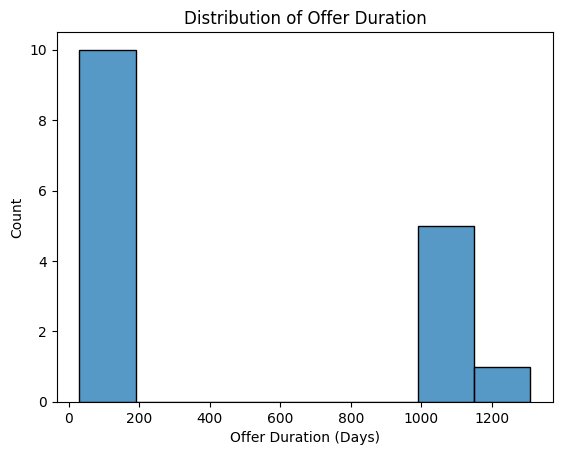

In [38]:
# Plot the distribution of derived offer duration.
sns.histplot(special_offer_eda['offer_duration_days'], bins=8)
plt.title('Distribution of Offer Duration')
plt.xlabel('Offer Duration (Days)')
plt.show()

In [39]:
feature_5_insights = """
offer_duration_days is a derived feature created from start_date and end_date. It measures how long each promotion was active. The observed durations range from 30 days to 1309 days, with a median of 83.5 days. This shows that the dataset contains both short campaign-style promotions and long-running discount rules.

This is relevant to the product-level clustering workflow because promotion duration gives context to discount behaviour. A product linked to short promotions may be seasonal, clearance-driven, or campaign-dependent, while a product linked to long-running offers may follow a stable reseller or volume-pricing strategy. These differences help interpret whether promotion exposure is temporary or part of the product's usual commercial behaviour.

For final modelling, offer_duration_days should be aggregated to product level after joining offers to products, for example as average promotion duration, maximum promotion duration, or a long-running promotion flag.
"""

In [40]:
# Display the derived duration feature insight.
print_tile(size="h3", key="feature_5_insights", value=feature_5_insights)

### B.7 Grouped Analysis Across Promotion Features

In [41]:
# Compare discount depth across offer types for grouped analysis.
special_offer_eda.groupby('type')['discount_pct'].agg(['count', 'mean', 'min', 'max']).sort_values('mean', ascending=False)

,count,mean,min,max
type,,,,
Excess Inventory,3,0.383333,0.30,0.5
Discontinued Product,2,0.375000,0.35,0.4
Seasonal Discount,3,0.250000,0.10,0.5
New Product,2,0.175000,0.15,0.2
Volume Discount,5,0.104000,0.02,0.2
No Discount,1,0.000000,0.00,0.0


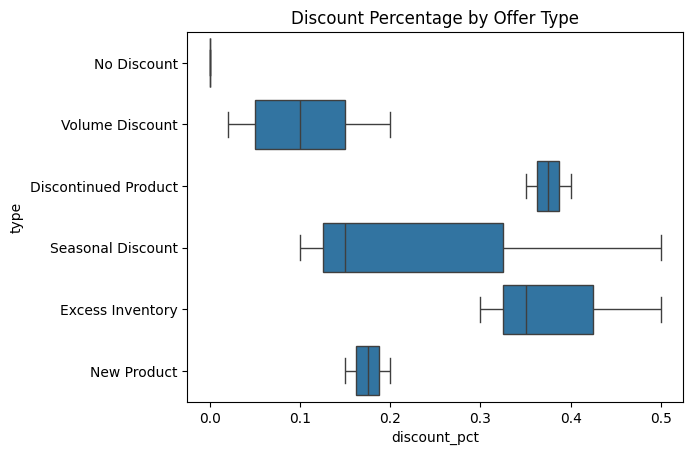

In [42]:
# Visualise how discount percentage varies by offer type.
sns.boxplot(data=special_offer_eda, x='discount_pct', y='type')
plt.title('Discount Percentage by Offer Type')
plt.show()

In [43]:
# Extract offer start and end years for grouped time-based review.
special_offer_eda['start_year'] = special_offer_eda['start_date'].dt.year
special_offer_eda['end_year'] = special_offer_eda['end_date'].dt.year

special_offer_eda.groupby('start_year').size()

,0
start_year,
2011,6
2012,3
2013,6
2014,1


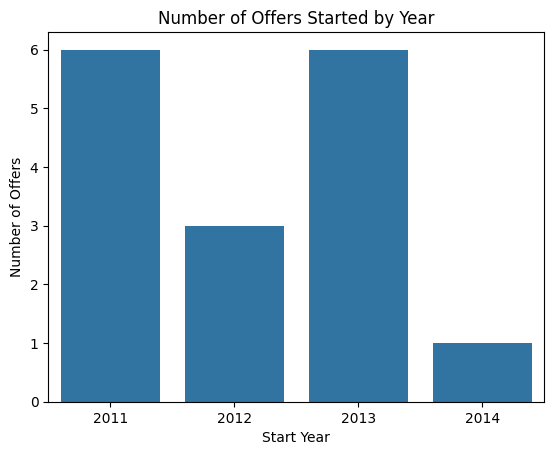

In [44]:
# Plot how many offers started in each year.
sns.countplot(data=special_offer_eda, x='start_year')
plt.title('Number of Offers Started by Year')
plt.xlabel('Start Year')
plt.ylabel('Number of Offers')
plt.show()

In [45]:
grouped_analysis_insights = """
After the feature-by-feature analysis, the grouped analysis shows how promotion features work together. Offer type explains the reason for a discount, discount_pct shows the size of the price incentive, and start year shows when promotion activity began. The grouped results show that Excess Inventory has the highest average discount at about 0.383, followed by Discontinued Product at about 0.375. Volume Discount has a lower average discount of about 0.104, which supports the interpretation that not all promotion types create the same level of discount exposure.

This grouped view is important because products should not be clustered only by whether they received a discount. The business needs to understand the pattern behind the promotion: whether it is a volume discount, seasonal campaign, excess-inventory response, new-product promotion, or discontinued-product clearance activity. These patterns can help identify products that may have heavier promotion exposure or possible margin pressure after the offer data is joined to product-level sales, cost, and price features.

In the final preparation notebook, these grouped patterns should be converted into product-level features such as average discount by product, maximum discount by product, number of offer types linked to a product, reseller/volume-discount exposure, and promotion timing or duration indicators.
"""

In [46]:
# Display the grouped promotion analysis insight.
print_tile(size="h3", key="grouped_analysis_insights", value=grouped_analysis_insights)